In [18]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline



In [19]:
def f(x):
    return 3*x**2 - 4*x +5


In [20]:
f(3.0)

20.0

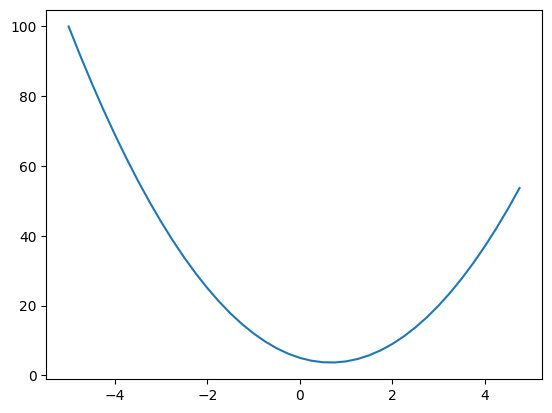

In [21]:
xs = np.arange(-5,5, 0.25)
ys = f(xs)
ys

plt.plot(xs, ys)

## Core of the Value Object class & Backpropagation


In [122]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backwards = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value (data = {self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backwards():

            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            

        out._backwards = _backwards
        return out
    def __mul__(self, other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other),'*')

        def backwards():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backwards = backwards
        return out
    
    def __rmul__(self, other):
         return self * other
    
    def __pow__(self, other):
        
        assert isinstance(other, (int, float))

        out = Value( self.data **other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data **(other - 1)) * out.grad
        
        out._backwards = _backward
    
        return out
    
    def __truediv__(self, other):

        return self * other**-1
   
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __radd__(self, other):
        return self + other

    def __rsub__(self, other):
        return Value(other) + (-self)

    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def backwards():
            self.grad += (1 - t**2) * out.grad
        out._backwards = backwards
        return out
    
    def exp(self):

        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data  * out.grad
        
        out._backwards = _backward
        return out
        

    def backwards( self):
        # topological order all of the children in the graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backwards()
     

In [123]:
from graphviz import Digraph

def trace( root ):

    # builds a set of all nodes and edges in a graph

    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child) # so it recals the function for every children so that it can iterate through all the children of childrens...
    
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid= str(id(n))

        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:

            # if this value is the result of some operation create an operation node for it, to show it
            dot.node(name = uid + n._op, label =n._op)
            # and connect this node to it
            dot.edge(uid+ n._op, uid)
    
    for n1, n2 in edges: 
        #connect n1 to the operation of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [124]:
topo = []

visited = set()

def build_topo(v):

    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)



In [125]:

def lol():

    h = 0.0001

    a = Value(2, label='a')
    b= Value(-3, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    
    a = Value(2 + h, label='a')
    b= Value(-3, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()



6.000000000021544


## Neural Network

In [126]:
import random
import torch
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1)) # the added bias
    
    def __call__(self, x):
        # w * x + b => the links
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    

class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP: # Multi Layer

    def __init__(self, nin, nouts):
        
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x=layer(x)
        return x
    
    def parameters(self):
        return [  p for layer in self.layers for p in layer.parameters()]

        

In [127]:
X = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(X)

Value (data = -0.5052035079260305)

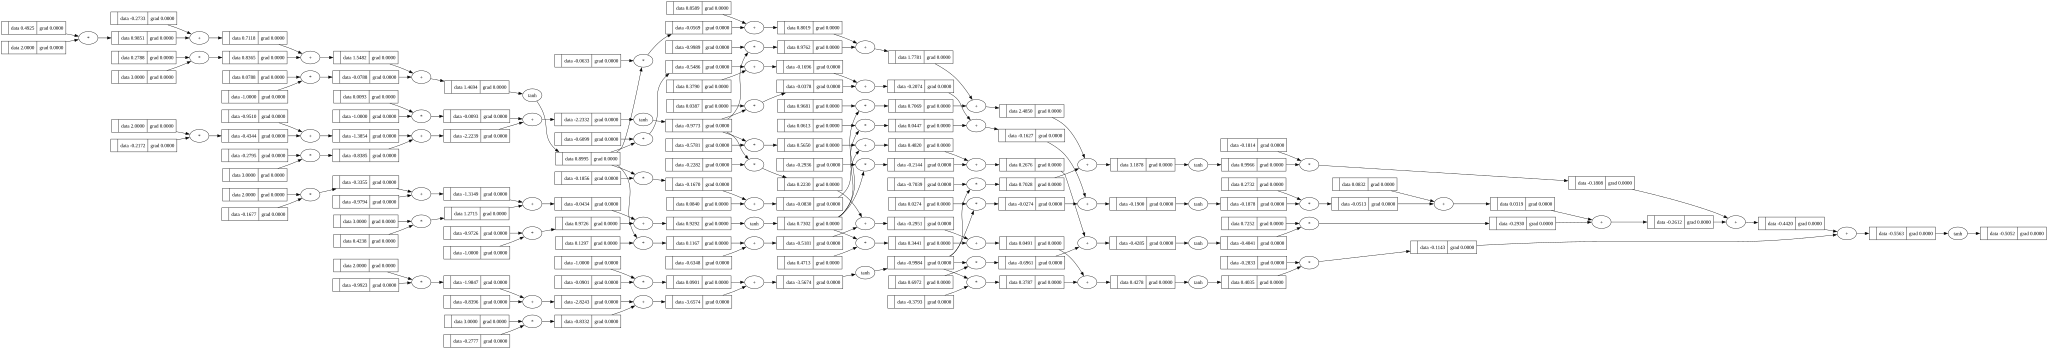

In [128]:
draw_dot(n(X))

In [ ]:
xs = [

    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, -1.0] # desired output for each input in xs



[Value (data = -0.5052035079260305),
 Value (data = 0.010099318555282018),
 Value (data = 0.16747789681337205),
 Value (data = -0.24928741251332412)]

In [144]:
for k in range(10):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt,yout in zip(ys,ypred)])  

    for  p in n.parameters():
        p.grad = 0.0
        
    # back pro^pagate
    loss.backwards()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print (k, loss.data)

0 4.0
1 4.0
2 4.0
3 4.0
4 4.0
5 4.0
6 4.0
7 4.0
8 4.0
9 4.0


In [145]:
ypred

[Value (data = -1.0),
 Value (data = -1.0),
 Value (data = -1.0),
 Value (data = -1.0)]

In [146]:
n.layers[0].neurons[0].w[0].grad


0.0

In [147]:
n.layers[0].neurons[0].w[0].data

24.431588809447373

In [ ]:
for p in n.parameters():
    p.data += 0.01  * p.grad